  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


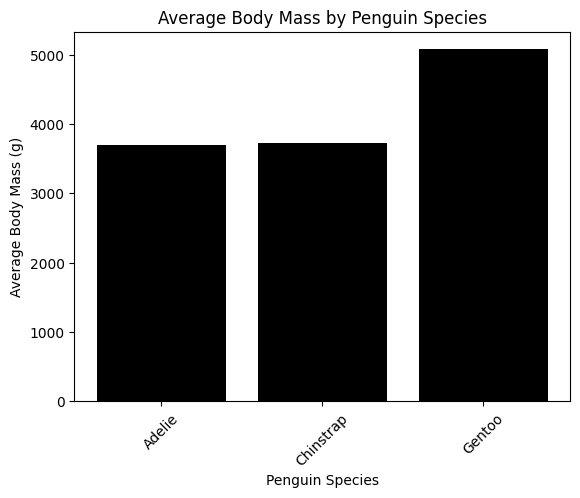

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset('penguins')
print(df.head())

average_mass = df.groupby('species')['body_mass_g'].mean()

plt.bar(average_mass.index, average_mass.values,color='black')

plt.xticks(rotation=45)

plt.xlabel('Penguin Species')
plt.ylabel('Average Body Mass (g)')
plt.title('Average Body Mass by Penguin Species')

plt.show()

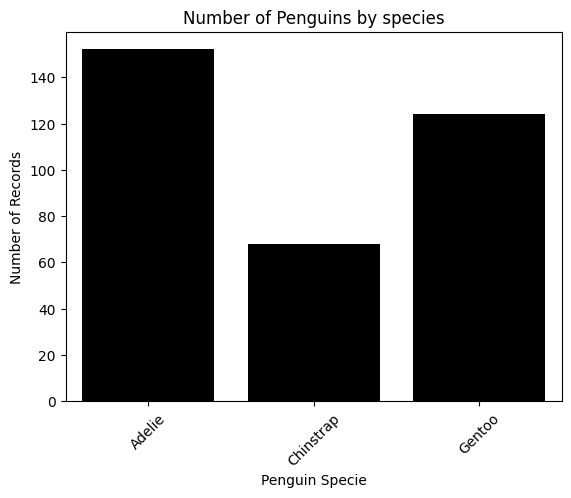

In [10]:
#task2
sns.countplot(data=df, x='species', color='black')

plt.xticks(rotation=45)

plt.xlabel('Penguin Specie')
plt.ylabel('Number of Records')
plt.title('Number of Penguins by species')

plt.show()

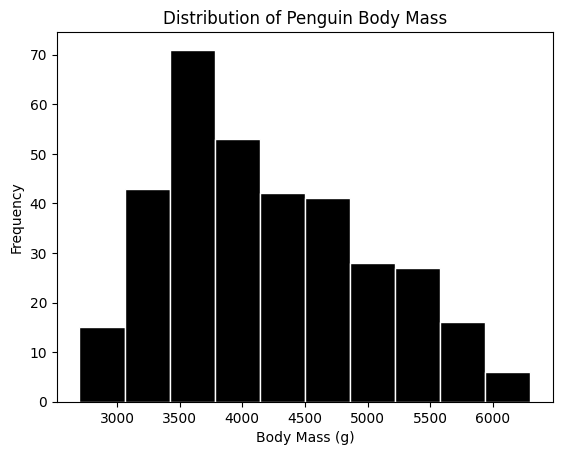

In [15]:
#task3
plt.hist(df['body_mass_g'].dropna(), color='black',edgecolor='white')

plt.xlabel('Body Mass (g)')
plt.ylabel('Frequency')
plt.title('Distribution of Penguin Body Mass')

plt.show()

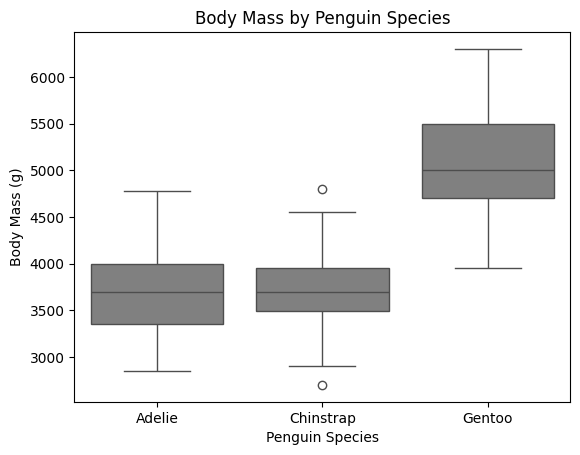

In [24]:
#task4
sns.boxplot(
    data=df,
    x='species',
    y='body_mass_g',
    color='GREY',
)

plt.xlabel('Penguin Species')
plt.ylabel('Body Mass (g)')
plt.title('Body Mass by Penguin Species')

plt.show()

In [26]:
# Task 5

for species in df['species'].dropna().unique():

    data = df[df['species'] == species]['body_mass_g'].dropna()

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data < lower) | (data > upper)]

    print(species, ":", len(outliers))

Adelie : 0
Chinstrap : 2
Gentoo : 0


In [30]:
# Task 6

from scipy import stats

for species in df['species'].dropna().unique():

    data = df[df['species'] == species]['body_mass_g'].dropna()
    zscore = stats.zscore(data)
    outliers_z = data[abs(zscore) > 3]

    print(species, ":", len(outliers_z))

Adelie : 0
Chinstrap : 0
Gentoo : 0


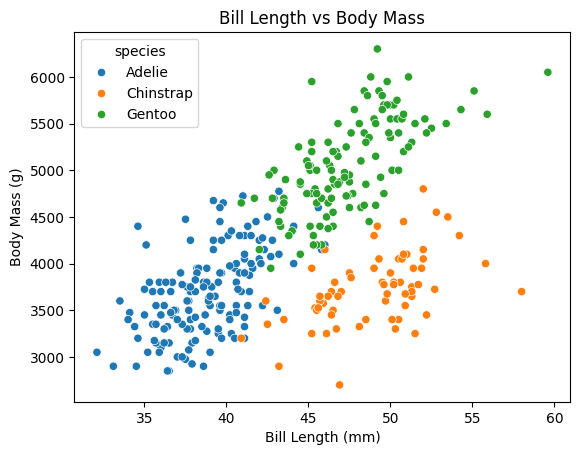

In [31]:
# Task 7

sns.scatterplot(
    data=df,
    x='bill_length_mm',
    y='body_mass_g',
    hue='species'
)

plt.xlabel('Bill Length (mm)')
plt.ylabel('Body Mass (g)')
plt.title('Bill Length vs Body Mass')

plt.show()

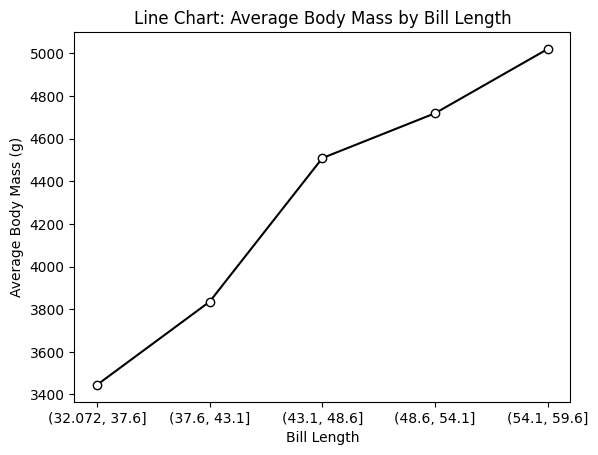

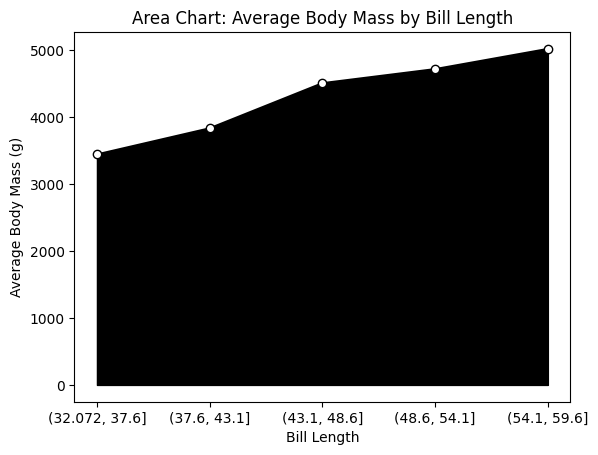

In [38]:
# Task 8

df['bill_length_bin'] = pd.cut(df['bill_length_mm'], bins=5)

average_mass = df.groupby('bill_length_bin', observed=True)['body_mass_g'].mean()

# Line Chart
plt.figure()

plt.plot(
    average_mass.index.astype(str),
    average_mass.values,
    color='black',
    marker='o',
    markerfacecolor='white',
    markeredgecolor='black'
)

plt.xlabel('Bill Length')
plt.ylabel('Average Body Mass (g)')
plt.title('Line Chart: Average Body Mass by Bill Length')

plt.show()

# Area Chart
plt.figure()

plt.fill_between(
    range(len(average_mass)),
    average_mass.values,
    color='black'
)

plt.plot(
    range(len(average_mass)),
    average_mass.values,
    color='black',
    marker='o',
    markerfacecolor='white',
    markeredgecolor='black'
)

plt.xticks(
    range(len(average_mass)),
    average_mass.index.astype(str)
)

plt.xlabel('Bill Length')
plt.ylabel('Average Body Mass (g)')
plt.title('Area Chart: Average Body Mass by Bill Length')

plt.show()

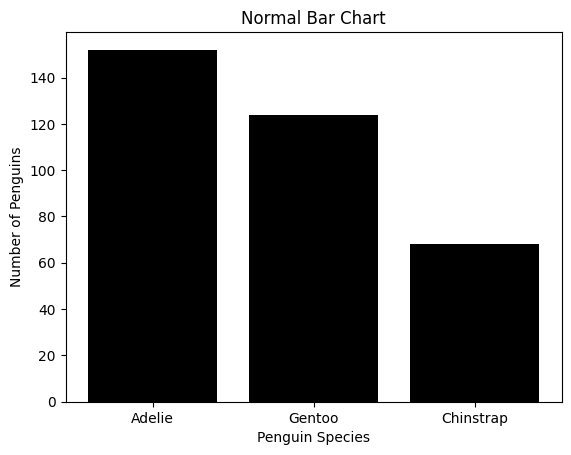

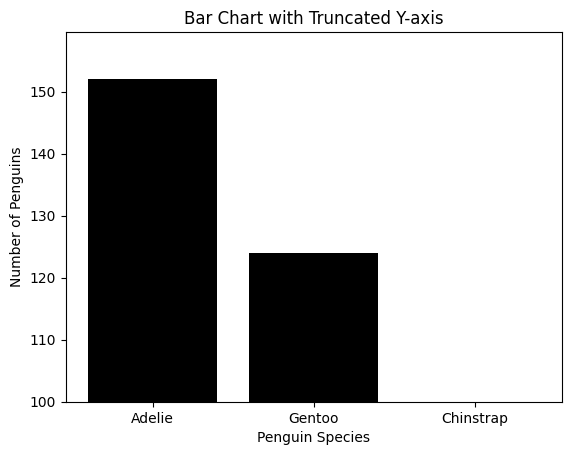

In [39]:
# Task 9

counts = df['species'].value_counts()
plt.figure()
plt.bar(
    counts.index,
    counts.values,
    color='black'
)

plt.xlabel('Penguin Species')
plt.ylabel('Number of Penguins')
plt.title('Normal Bar Chart')

plt.show()
plt.figure()
plt.bar(
    counts.index,
    counts.values,
    color='black'
)

plt.xlabel('Penguin Species')
plt.ylabel('Number of Penguins')
plt.title('Bar Chart with Truncated Y-axis')

plt.ylim(bottom=100)
plt.show()